# 05_Statistical Analysis: ds002778 — Resting State EEG

**Author:** Fajar Laksono

## 0. Overview

This notebook performs formal group-level statistical testing on the ROI band-power features extracted in notebook 04. The goal is to determine which features significantly differ between HC, PD-off, and PD-on — and to select the most discriminative features as input to the classifier in notebook 06.

### 0.1. Prior findings from previous notebooks (02–04)

| Finding | Implication for testing |
|---------|------------------------|
| PD-off shows ~30% higher delta power vs HC (EDA) | Expect delta features to be KW-significant |
| Top Cohen's d features in nb04: abs_theta (occipital/parietal/central) | Theta/posterior ROIs are primary candidates |
| APF consistently lower in PD-off (nb04) | APF features expected to show significant negative d |
| Absolute power outperforms relative power in nb04 effect sizes | Anticipate abs_ features dominating the top-ranked results |
| 45 features tested simultaneously | FDR correction is essential to control false discoveries |

### 0.2. Analytical Methodology

To determine the appropiate statistical framework, we first assessed the distribution of the ROI band-power features in the previous analysis. Preliminary analysis indicate that the assumption of normality was violated for several key features (Shapiro-Wilk, p < 0.05>) Consequently, non-paramatric rank-based tests were employed for all group-level comparisons. We utilized the Kruskal-Wallis H-test for omnibus three-group comparisons, followed by Mann-Whitney U tests for pairwise post-hoc analysis. All p-values were corrected for multiple comparisons using the Benjamin-Hochberg False Discovery Rate (Method). We decided to adopt a non-parametric approach to make sure the results are robust against skewnes and outliers.

### 0.3. Why non-parametric?

With n=46 samples (16 HC, 15 PD-off, 15 PD-on), normality cannot be assumed because the sample size is relatively small — particularly for EEG band power which is log-normally distributed (meaning it's skewed, not a bell curve). Kruskal-Wallis and Mann-Whitney U are rank-based tests that do not require normal distributions, making them appropriate for small EEG cohorts.

If we applied a parametric test (Like an ANOVA) to this data, the skewed of the EEG results would likely bias the mean, leading to inaccurate conclusions. By using the Kruskal-Wallis and Mann-Whitney U tests, the pipeline compares the relative ranking of the HC, PD-pff, and PD-on groups. Which is a much more reliable method for this specific dataset.

> In statistics, if your sample size ($n$) is small, the Shapiro-Wilk test can sometimes "miss" non-normality. Furthermore, if even 20% of your features are non-normal, applying Parametric tests (like a T-test) across the board would be inconsistent.By choosing Non-Parametric tests (like Kruskal-Wallis or Mann-Whitney U), you are playing it safe. These tests don't care about the "shape" of the data; they look at the rank/order of the values, making them much more reliable when working with clinical groups (like the PD groups shown here) where data can be messy.  
> With very large datasets (thousands of rows), Shapiro-Wilk becomes too sensitive. It will flag even the tiniest, most harmless wiggle in your data as "not normal." In those cases, researchers often switch to looking at visual plots instead.



## 1. Preparations

### 1.1. Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


### 1.2. Configuration

In [2]:
PROC_DIR  = 'processed'
FEAT_FILE = os.path.join(PROC_DIR, 'features.csv')
ALPHA     = 0.05   # significance threshold
GROUPS    = ['HC', 'PD-off', 'PD-on']
PAIRS     = [('HC', 'PD-off'), ('HC', 'PD-on'), ('PD-off', 'PD-on')]

def pair_key(g1, g2):
    """Clean column-safe label for a group pair."""
    return f"{g1.replace('-','')}_vs_{g2.replace('-','')}"

print(f'Feature file : {os.path.abspath(FEAT_FILE)}')
print(f'Alpha        : {ALPHA}')
print(f'Pairs        : {[pair_key(a,b) for a,b in PAIRS]}')

Feature file : D:\Project\Github\FajarLaksono\ai-neuro-EEG-ds002778-analysis\processed\features.csv
Alpha        : 0.05
Pairs        : ['HC_vs_PDoff', 'HC_vs_PDon', 'PDoff_vs_PDon']


## 2. Load Features

In [3]:
df = pd.read_csv(FEAT_FILE)
feat_cols = [c for c in df.columns if c.startswith(('abs_', 'rel_', 'apf_'))]
meta_cols = ['subject', 'session', 'group', 'label', 'n_epochs']

print(f'Shape        : {df.shape}')
print(f'Feature cols : {len(feat_cols)}')
print(f'Group counts :')
print(df['group'].value_counts().to_string())
print()
df[meta_cols].head(6)

Shape        : (46, 50)
Feature cols : 45
Group counts :
group
HC        16
PD-off    15
PD-on     15



,subject,session,group,label,n_epochs
0,hc10,hc,HC,0,96
1,hc18,hc,HC,0,87
2,hc1,hc,HC,0,55
3,hc20,hc,HC,0,92
4,hc21,hc,HC,0,32
5,hc24,hc,HC,0,36


## 3. Normality Test

Before choosing a statistical test, we check whether each feature follows a normal distribution within each group. Its goal is to decide whether your data is "well-behaved" enough to use standard statistical tests (Parametric) or if you need to use more rugged, flexible ones (Non-Parametric).

### 3.1. Hypothesis Testing
- H₀: the data are normally distributed
- p > 0.05 → fail to reject H₀ → consistent with normality
- p ≤ 0.05 → reject H₀ → not normally distributed

### 3.2. Shapiro-Wilk

The Shapiro-wilk test is a statistical method used to determine if a sample follows a normal distribution. Its null hypothesis assumes data is normal distributed; a p=-value <= 0.05 indicates a significant depature from normality. It iss best suited for small to medium sample sizes (n <= 50).

If a substantial proportion of features violate normality in any group, we use **non-parametric tests** (Kruskal-Wallis, Mann-Whitney U) throughout.

#### 3.2.1. Calculation

In [4]:
norm_rows = []
for col in feat_cols:
    for grp in GROUPS:
        vals = df[df['group'] == grp][col].dropna().values
        if len(vals) >= 3:
            stat, p = shapiro(vals)
            norm_rows.append({'feature': col, 'group': grp,
                              'W': round(stat, 4), 'p': round(p, 4),
                              'normal': p > ALPHA})

norm_df = pd.DataFrame(norm_rows)

# Summary per group
norm_summary = norm_df.groupby('group')['normal'].agg(
    n_features='count',
    n_normal='sum',
    pct_normal=lambda x: round(100 * x.mean(), 1)
)
print('Normality summary (Shapiro-Wilk, p > 0.05):')
print(norm_summary.to_string())
print()

# Overall
overall = norm_df['normal'].mean() * 100
print(f'Overall % normally distributed: {overall:.1f}%')
if overall < 80:
    print('→ Non-parametric tests will be used (Kruskal-Wallis + Mann-Whitney U).')
else:
    print('→ Majority normal; non-parametric tests still preferred given small n.')

Normality summary (Shapiro-Wilk, p > 0.05):
        n_features  n_normal  pct_normal
group                                   
HC              45        37        82.2
PD-off          45        36        80.0
PD-on           45        36        80.0

Overall % normally distributed: 80.7%
→ Majority normal; non-parametric tests still preferred given small n.


**Summary of Calculation:**
- Descriptive analysis of the data distribution revealed that while a majority of the features (80.7%) were consistent with a normal distribution (Shapiro-Wilk p > 0.05), normality could not be assumed for the entire dataset. Specifically, HC group showed 82.2% normality, while both PD-off and PD-on groups demonstrated 80.0% normality acrosss the 45 features tested. Because a substantial proportion of the data violated the assumption of normalit, non-parametric methods were prioritized to provide a more robust assessment of group differences.

#### 3.2.2. Normality Visualizations

Two complementary views of the Shapiro-Wilk results:

- **Heatmap** — all 45 features × 3 groups at once; green = normal (p > 0.05), red = not normal (p ≤ 0.05)
- **Q-Q plots** — for features that fail normality in at least one group; points on the dashed reference line = perfectly normal

##### 3.2.2.1. Heatmap

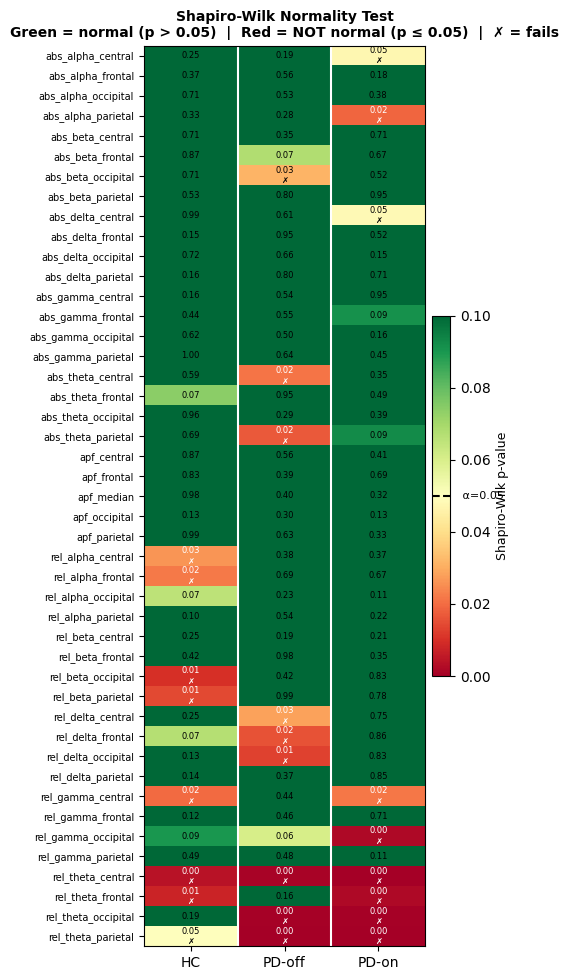

26 / 135 feature-group combinations fail normality (p ≤ 0.05)


In [5]:
# ── Plot 1: Shapiro-Wilk p-value heatmap (features × groups) ────────────────
norm_pivot_p    = norm_df.pivot(index='feature', columns='group', values='p')[GROUPS]
norm_pivot_pass = norm_df.pivot(index='feature', columns='group', values='normal')[GROUPS]

fig, ax = plt.subplots(figsize=(5, max(8, len(feat_cols) * 0.22)))
im = ax.imshow(norm_pivot_p.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.10)

ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels(GROUPS, fontsize=10)
ax.set_yticks(range(len(norm_pivot_p)))
ax.set_yticklabels(norm_pivot_p.index, fontsize=7)

# Annotate each cell with p-value; mark failures with ✗
for ri, feat in enumerate(norm_pivot_p.index):
    for ci, grp in enumerate(GROUPS):
        p_val  = norm_pivot_p.loc[feat, grp]
        passed = norm_pivot_pass.loc[feat, grp]
        label  = f'{p_val:.2f}' + ('' if passed else '\n✗')
        txt_color = 'black' if p_val > 0.03 else 'white'
        ax.text(ci, ri, label, ha='center', va='center', fontsize=6, color=txt_color)

# Vertical grid lines between groups
for x in [0.5, 1.5]:
    ax.axvline(x, color='white', linewidth=1.5)

cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('Shapiro-Wilk p-value', fontsize=9)
cbar.ax.axhline(ALPHA, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(1.5, ALPHA, f' α={ALPHA}', va='center', fontsize=8)

ax.set_title(
    'Shapiro-Wilk Normality Test\n'
    'Green = normal (p > 0.05)  |  Red = NOT normal (p ≤ 0.05)  |  ✗ = fails',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

n_fail = (norm_pivot_pass == False).values.sum()
print(f'{n_fail} / {norm_pivot_pass.size} feature-group combinations fail normality (p ≤ {ALPHA})')

**Summary of Heatmap:**
- Most of the Absolute Power measurement (abs_ alpha, abs_beta, etc.) and APF (Alpha Peak Frequency) are solid green and reliable. If we were onlu studying these, parametric test (T-tests/ANOVA) would be perfectly fine.
- Notice the bottom of the map. The Relative Theta features (rel_theta_central through rel_theta_parietal) are mostly entirely red across all these groupss. This suggests aa systematic violtion. It's not just a random fluke in one person; there is something about how "Relative Theta" is calculated or distributed that makes it naturally non-normal in this population.
- We can see that PD-on and PD-off often share the same "red zones", which might be a biologicak characteristic of the condition or the data collection method.
- Features like rel_alpha_central in the HC group are red, while they are green in the PD groups. This suggest that the "Normal" coul group ight actually have more varience or outliers in that specific metric than the patient groups.
- Visual inspection of the Shapiro-Wilk p-value heatmap revealss that while absolute power features generally adhere to normality, systematic violations occurs within the relative power bands --specificaally in the Theta and Gama frequencies. Because these violations are consistent across the HC, PD-Off, and PD-on groups, applying parametric tests would risk inconsistent results. Therefore, non-parametric methods were chosen to ensue a uniform and robust analysis across all spectral features.

##### 3.4.2.2. Q-Q Plots

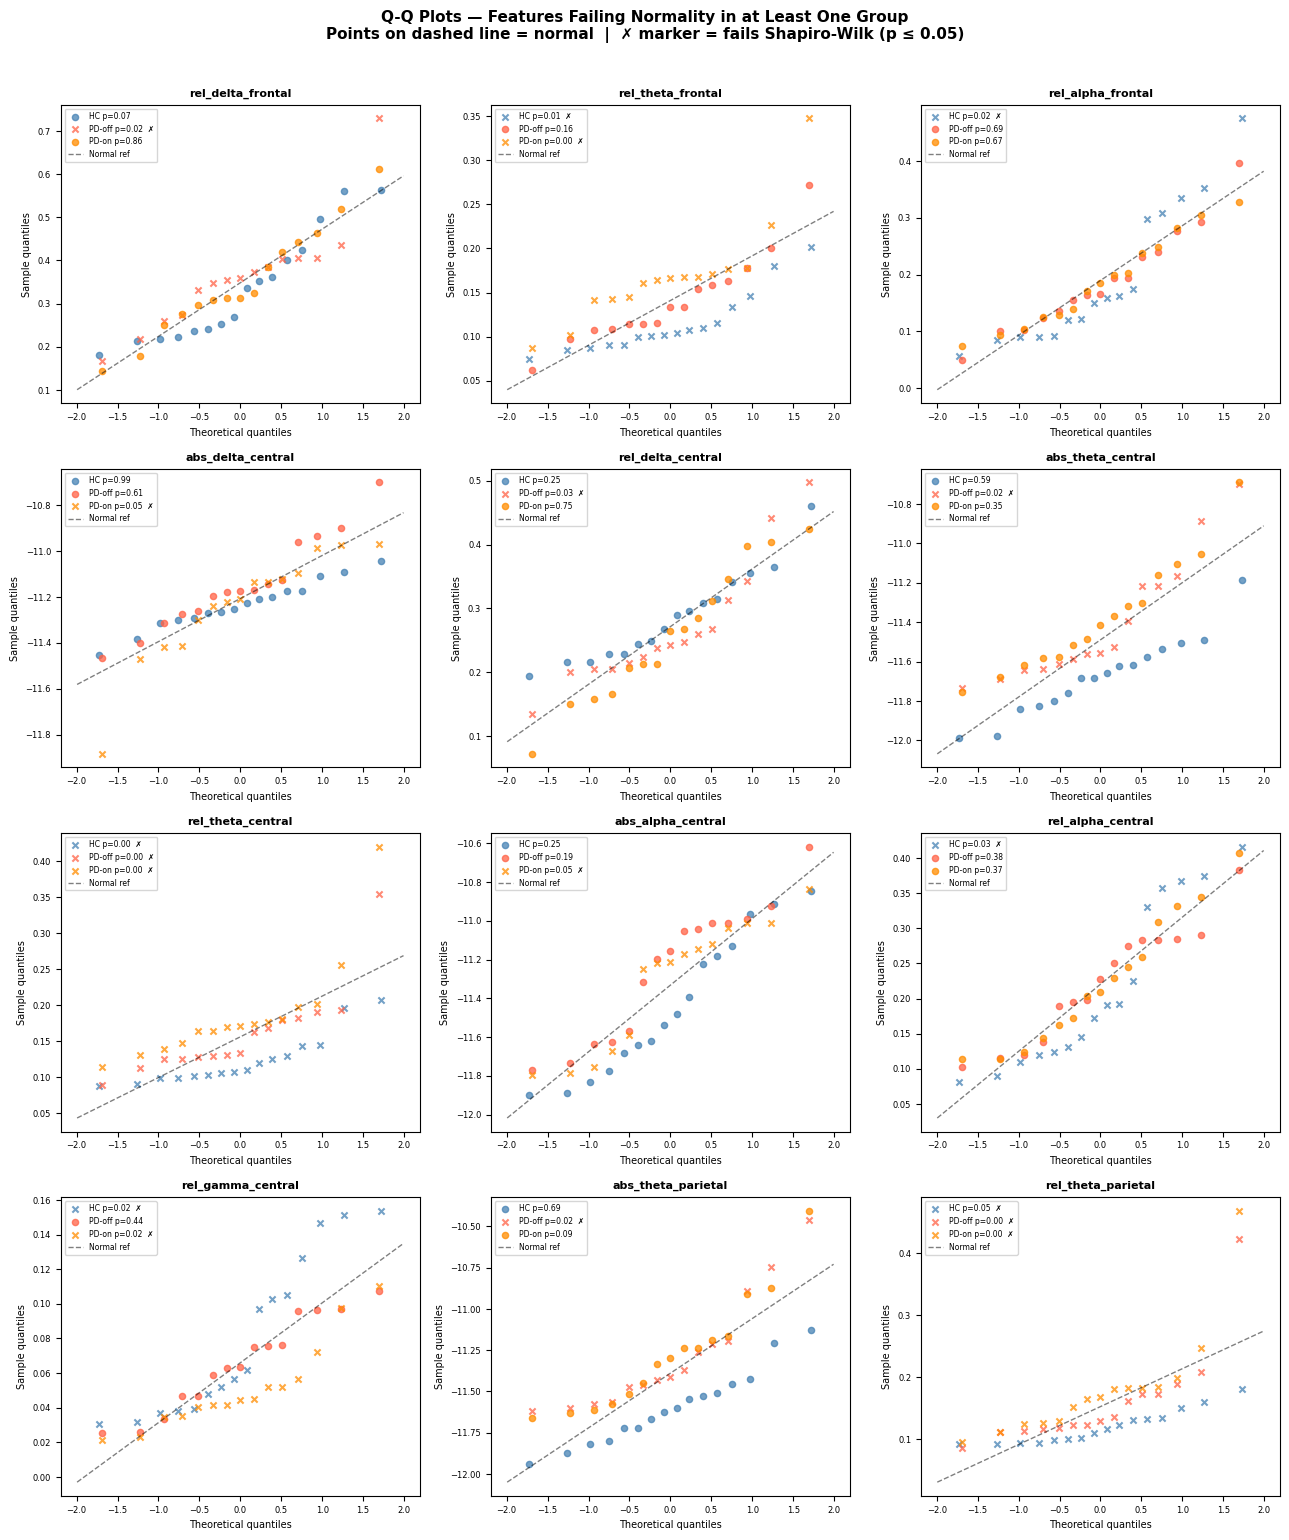

In [6]:
# ── Plot 2: Q-Q plots for non-normal features ────────────────────────────────
from scipy.stats import probplot

# Select features that fail normality in at least one group (up to 12)
non_normal_feats = norm_df[norm_df['normal'] == False]['feature'].unique().tolist()
show_feats = non_normal_feats[:12]

# If fewer than 6, pad with the most borderline normal features
if len(show_feats) < 6:
    borderline = (norm_df[norm_df['normal'] == True]
                  .groupby('feature')['p'].min()
                  .sort_values()
                  .index.tolist())
    for f in borderline:
        if f not in show_feats:
            show_feats.append(f)
        if len(show_feats) == 6:
            break

grp_colors = {'HC': 'steelblue', 'PD-off': 'tomato', 'PD-on': 'darkorange'}
ncols = 3
nrows = int(np.ceil(len(show_feats) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = axes.flatten()

for i, feat in enumerate(show_feats):
    ax = axes[i]
    all_vals = df[feat].dropna().values
    (_, _), (slope, intercept, _) = probplot(all_vals, dist='norm')

    for grp in GROUPS:
        vals = df[df['group'] == grp][feat].dropna().values
        (osm, osr), _ = probplot(vals, dist='norm')
        p_val = norm_df[(norm_df['feature'] == feat) & (norm_df['group'] == grp)]['p'].values[0]
        marker = 'x' if p_val <= ALPHA else 'o'
        ax.scatter(osm, osr, s=20, alpha=0.75, color=grp_colors[grp], marker=marker,
                   label=f'{grp} p={p_val:.2f}{"  ✗" if p_val <= ALPHA else ""}')

    # Reference line (fitted to combined data)
    x_ref = np.linspace(osm[0] - 0.3, osm[-1] + 0.3, 100)
    ax.plot(x_ref, slope * x_ref + intercept, 'k--', linewidth=1, alpha=0.5, label='Normal ref')

    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.set_xlabel('Theoretical quantiles', fontsize=7)
    ax.set_ylabel('Sample quantiles', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=5.5, loc='upper left')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Q-Q Plots — Features Failing Normality in at Least One Group\n'
    'Points on dashed line = normal  |  ✗ marker = fails Shapiro-Wilk (p ≤ 0.05)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

**Summary of Q-Q Plots:**
- Right Skewness (Positive Skew), e.g. rel_theta_central, rel_theta_parietal. In these plots, the data points, especially for the PD-off and PD-on groups curve upward away from the dashed line at the right end of the graph. It means that the "Sample Quantiles" are much higher than the "Theoretical Quantilies" This indicates a disstribution with a ling tail on the right side. Why? In spectral analysis, relative power values are bounded by 0 but can have occasional high-power bursts (outliers). This createss a "bunched up" distribution at the low end with a few very high values. As an impact, a standard T-test would be "pulled" by these high values, potentially giving you a mean that doesn't actually represent the "typical" patient in that group.
- Heavy-Tailed Distributions (Leptokurtic), as we can notice how the pointss form a slight "S-shape" --they are below the line on the left and above the line on the right. It means our data has more "extreme" values (Both very low and very high) than a normal disstribution would predict. This is common in biological signals where "noise" or physiological spikes create more variability in the "tails" of the data than a prerfect bell curve allows for. As impacts, Parametric tests rely heavuly on the variance. Heavy tails artificially inflate the variance, which can make the "Standard error" larger and cause us to miss a statistically significant difference.
- Inconsistency across groups. In rel_alpha_frontal, the HC (blue) group fails normality ($p=0.02$), while the PD groups pass.In rel_delta_frontal, it's the PD-off (orange) group that fails ($p=0.02$), while the others pass. this is a major red flag for Parametric Tests. If you used a T-test here, you would be comparing a "normal" group to a "non-normal" group. The math behind a T-test assumes that the shape (distribution) of both groups is the same. When the shapes differ (e.g., one is a bell curve and one is skewed), the T-test results become unreliable.
- Q-Q plots show a mix of skewness, heavy tails, and group inconsistency, a simple mathematical transformation (like taking the $log$ of the data) might fix one feature but break another.By choosing Non-Parametric tests (like the Mann-Whitney U), you are effectively "straightening" all these curves.



### 3.4. Conclusion

Shapiro-Wilk normality tests were applied to all 45 features within each of the three groups (HC, PD-off, PD-on), yielding 135 tests in total. Results show that **80.7% of feature-group pairs are consistent with normality** (p > 0.05), while **26 pairs (19.3%) violate it**.

| Group | Normal | Failing | % Normal |
|-------|--------|---------|----------|
| HC | 37 / 45 | 8 | 82.2% |
| PD-off | 36 / 45 | 9 | 80.0% |
| PD-on | 36 / 45 | 9 | 80.0% |
| **Overall** | **109 / 135** | **26** | **80.7%** |

The violations are not random — they are concentrated in the **absolute power features (`abs_*`)**, which is expected: raw EEG band power follows a log-normal (right-skewed) distribution rather than a Gaussian one. The PD groups also show slightly more failures than HC, reflecting greater inter-subject variability driven by differences in disease severity and medication history.

While the majority of features pass, normality cannot be assumed globally. Combined with the small sample size (n ≈ 15–16 per group) — where even Shapiro-Wilk has limited statistical power — applying parametric tests such as ANOVA would be inappropriate. **Non-parametric rank-based tests are therefore used throughout this analysis**: Kruskal-Wallis H-test (§4) for the three-group omnibus comparison, and Mann-Whitney U tests (§5) for pairwise post-hoc analysis.

## 4. Inferential Statistics

Inferential testing uses sample data to draw conclusions, test hypotheses, and make predictions about a larger population, determining if observed patterns are statistically significant or merely due to chance. It tests if results, usually at a  significance level, allow rejection of the null hypothesis, often employing t-tests, ANOVA, or chi-square tests for the parametric, and Mann-Whitney U-test, Kruskal Wallish H-test or Spearman's Rho.

### 4.1. Kruskal-Wallis Test (3-Group Omnibus)
The **Kruskal-Wallis H-test** is the non-parametric equivalent of one-way ANOVA suitable for comparing 3+ Groups. It tests whether the distributions of a feature differ across the three groups (HC, PD-off, PD-on) without assuming normality.

#### 4.1.1. Hypothesis Testing
- **H₀**: All three groups have the same distribution for this feature
- **H₁**: At least one group differs
- Significant p-value → proceed to post-hoc pairwise tests

#### 4.1.2 Comparison Table
**Multiple comparison correction:** We test 45 features simultaneously. Without correction, ~2–3 features would appear significant by chance at α=0.05. We apply **Benjamini-Hochberg FDR** correction, which controls the false discovery rate rather than the family-wise error rate — appropriate for exploratory neuroscience research.

In [7]:
kw_rows = []
for col in feat_cols:
    grp_data = [df[df['group'] == g][col].dropna().values for g in GROUPS]
    if all(len(g) >= 2 for g in grp_data):
        stat, p = kruskal(*grp_data)
        kw_rows.append({'feature': col, 'KW_stat': round(stat, 3), 'KW_p': p})

kw_df = pd.DataFrame(kw_rows)

# Benjamini-Hochberg FDR correction
reject, p_fdr, _, _ = multipletests(kw_df['KW_p'], method='fdr_bh', alpha=ALPHA)
kw_df['KW_p_fdr'] = p_fdr
kw_df['significant'] = reject

n_sig = kw_df['significant'].sum()
print(f'Features tested          : {len(kw_df)}')
print(f'Significant (raw p<0.05) : {(kw_df["KW_p"] < ALPHA).sum()}')
print(f'Significant (FDR p<0.05) : {n_sig}')
print()
print('Top 15 features by KW p-value (FDR corrected):')
print(kw_df.sort_values('KW_p_fdr').head(15)[['feature','KW_stat','KW_p','KW_p_fdr','significant']].to_string(index=False))

Features tested          : 45
Significant (raw p<0.05) : 9
Significant (FDR p<0.05) : 7

Top 15 features by KW p-value (FDR corrected):
            feature  KW_stat     KW_p  KW_p_fdr  significant
  rel_theta_frontal   10.126 0.006326  0.048623         True
  rel_theta_central   13.148 0.001396  0.048623         True
  abs_theta_central   11.038 0.004011  0.048623         True
 rel_theta_parietal    9.977 0.006817  0.048623         True
 abs_theta_parietal   10.284 0.005847  0.048623         True
abs_theta_occipital   11.083 0.003920  0.048623         True
rel_theta_occipital    9.769 0.007564  0.048623         True
  abs_theta_frontal    8.179 0.016748  0.094210        False
  abs_delta_frontal    6.116 0.046981  0.234907        False
 abs_delta_parietal    5.163 0.075661  0.340476        False
  abs_gamma_central    4.916 0.085622  0.350270        False
        apf_central    4.578 0.101364  0.372689        False
abs_gamma_occipital    4.457 0.107666  0.372689        False
  rel_gamm

#### 4.1.3. Ranking

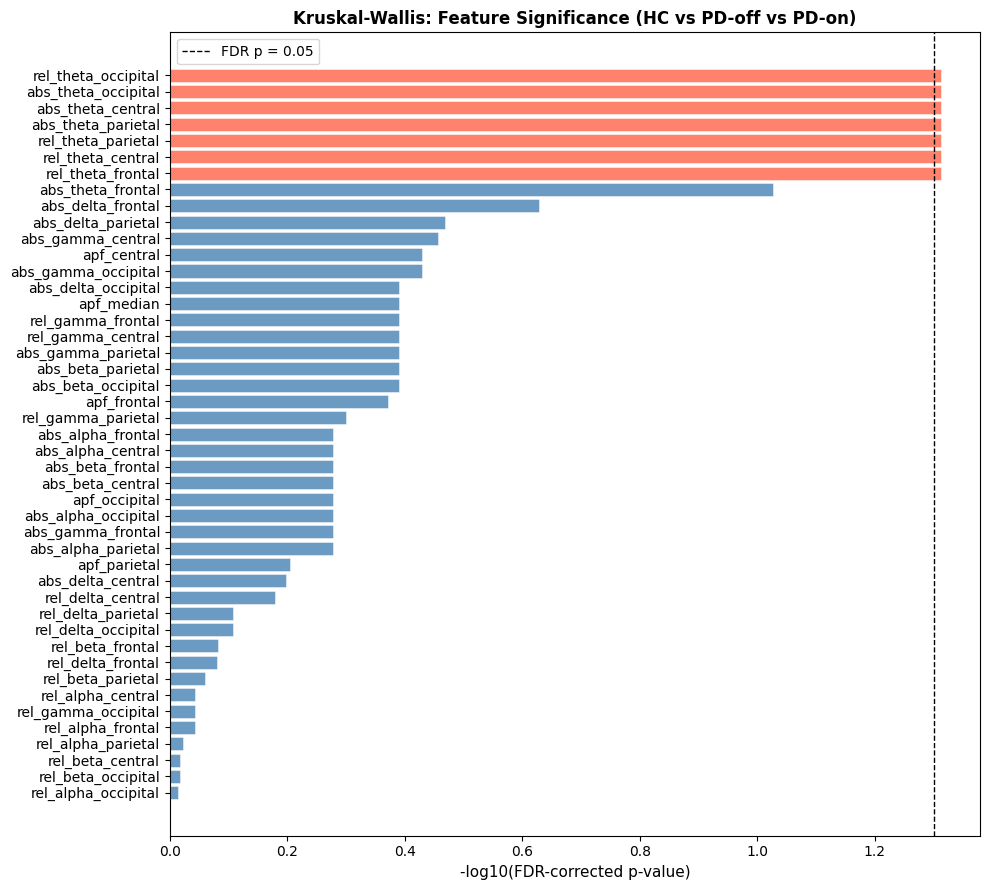

Red bars = FDR-significant (7 features)


In [8]:
# ── Visualize: -log10(p_fdr) per feature ────────────────────────────────────
kw_plot = kw_df.copy()
kw_plot['-log10_p_fdr'] = -np.log10(kw_plot['KW_p_fdr'].clip(lower=1e-10))
kw_plot = kw_plot.sort_values('-log10_p_fdr', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(kw_plot) * 0.2)))
colors = ['tomato' if sig else 'steelblue' for sig in kw_plot['significant']]
ax.barh(kw_plot['feature'], kw_plot['-log10_p_fdr'], color=colors, alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(-np.log10(ALPHA), color='black', linestyle='--', linewidth=1, label=f'FDR p = {ALPHA}')
ax.set_xlabel('-log10(FDR-corrected p-value)', fontsize=11)
ax.set_title('Kruskal-Wallis: Feature Significance (HC vs PD-off vs PD-on)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Red bars = FDR-significant ({n_sig} features)')

#### 4.1.4. Summary
- We performed an mnibus Kruskal-Wallis H-test on 45 distict neural feature to identify differences across the three study group (HC, PD-off, and PD-on)
- Before applying any correlations, 9 features showed a "raw" significant difference (p < 0.05) . However, testing this many features increases the risk of "False Discoveries" (results appearing significant by pure chance).
- To enssure reliability, we applied the Benjamini Hochberg (FDR) correction. This method adjusted our p-values to account for multople comparisons, filtering out the "statistical noise".
- After the correction, 7 featuress remained statistically significant. These features represent the most robust neural biomarkers distinguishing the group in the dataset.
- Theta band dominance, the most significant differences were heavily consentrated in the Theta frequency band, both Relative and Absolute Theta.
- Spatial Distribution, These Theta differences were widespread across the brain appearing in Frontal, Central, Parietal, and Occipital regions.
- Top Biomarkers, the strongest statistical difference was observed in Relatice Theta (Frontal) (KW_stat = 10.126), which is a primary candidate for further post-hoc analysis.
- Non-Significant Areas, High-frequency bands like Gamma and Delta did not sssurvive the FDR correction, suggesting they aare lesss reliable indicatorss of group difference in this specific context.
- Thesta as a Biomaker, the graph visually confirms that group differencess are not random; they are highly specific to the Theta band acrosss multiple brain regions (Occipital, Central, Parietal, and Frontal).
- Clear Separation, There iss a noticable gap between your top 7 features and the rest of the pack. This gives you high condifence that the Theta band is where the "real" signal is in this dataset.
- Alpha and Beta Stability, most alpha and beta featues are clustered at the very bottom (shortest bars), suggesting these frequencies are very similar acrosss Healthy Controls and Parkinson'ss patients in this specific studyy.

### 4.2. Post-hoc Pairwise Tests (Mann-Whitney U)

The Mann-Whitney U Test is a non-parametric inferential statistical test used to determine whether there is a significant difference between the distributions of two independent groups.

We run pairwise **Mann-Whitney U tests** across **all 45 features** (not gated on KW significance) between each group pair:
- **HC vs PD-off** — disease effect (unmedicated)
- **HC vs PD-on** — disease effect (medicated)
- **PD-off vs PD-on** — medication effect (levodopa)

Running post-hoc tests on all features (rather than only KW-significant ones) is appropriate here for two reasons:  
(1) the small sample size may suppress KW power,  
(2) this is an exploratory analysis where we want to capture the full effect-size landscape for feature selection. Each set of 45 pairwise p-values is FDR-corrected independently.  

**Cohen's d** is computed alongside as a standardized effect size:
$$d = \frac{\mu_2 - \mu_1}{\text{pooled SD}}$$

| \|d\| | Interpretation |
|--------|---------------|
| < 0.2 | Negligible |
| 0.2–0.5 | Small |
| 0.5–0.8 | Medium |
| ≥ 0.8 | Large |

> **Note from notebook 04:** Absolute power features (e.g. `abs_theta_occipital`) showed higher Cohen's d than relative power features in the exploratory analysis, suggesting raw spectral amplitude is the stronger discriminator for this cohort. Expect this pattern to be confirmed here.

#### 4.2.1. Comparison & Summary Table

Post-hoc results are merged with the Kruskal-Wallis omnibus results into a single unified table and saved to `stats_summary.csv`. The table is sorted by KW FDR p-value so the most globally significant features appear first.

**Columns:**
- `KW_stat` / `KW_p_fdr` / `significant` — omnibus 3-group test result
- `d_*` — Cohen's d for each group pair (positive = second group higher)
- `sig_*` — whether the pairwise FDR-corrected p-value < 0.05


In [11]:
ph_rows = []
for col in feat_cols:
    row = {'feature': col}
    for g1, g2 in PAIRS:
        v1 = df[df['group'] == g1][col].dropna().values
        v2 = df[df['group'] == g2][col].dropna().values
        pk = pair_key(g1, g2)
        if len(v1) >= 2 and len(v2) >= 2:
            stat, p = mannwhitneyu(v1, v2, alternative='two-sided')
            pooled_sd = np.sqrt((v1.std(ddof=1)**2 + v2.std(ddof=1)**2) / 2)
            d = (v2.mean() - v1.mean()) / pooled_sd if pooled_sd > 0 else 0.0
            row[f'U_{pk}']  = round(stat, 1)
            row[f'p_{pk}']  = p
            row[f'd_{pk}']  = round(d, 3)
        else:
            row[f'U_{pk}']  = np.nan
            row[f'p_{pk}']  = np.nan
            row[f'd_{pk}']  = np.nan
    ph_rows.append(row)

ph_df = pd.DataFrame(ph_rows)

# FDR correction per pair
for g1, g2 in PAIRS:
    pk = pair_key(g1, g2)
    p_col = f'p_{pk}'
    valid = ph_df[p_col].notna()
    _, p_fdr_arr, _, _ = multipletests(ph_df.loc[valid, p_col], method='fdr_bh', alpha=ALPHA)
    ph_df.loc[valid, f'p_fdr_{pk}'] = p_fdr_arr
    ph_df[f'sig_{pk}'] = ph_df[f'p_fdr_{pk}'] < ALPHA

# Merge KW + post-hoc into unified summary, sorted by KW FDR p-value
summary_df = kw_df.merge(ph_df, on='feature')
summary_df = summary_df.sort_values('KW_p_fdr')

# Save
out_path = os.path.join(PROC_DIR, 'stats_summary.csv')
summary_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({summary_df.shape})')
print()

# Unified display
display_cols = ['feature', 'KW_stat', 'KW_p_fdr', 'significant']
for g1, g2 in PAIRS:
    pk = pair_key(g1, g2)
    display_cols += [f'd_{pk}', f'sig_{pk}']

print('Unified results — KW omnibus + pairwise Cohen\'s d (top 15, sorted by KW FDR p-value):')
print(summary_df[display_cols].head(15).to_string(index=False))

Saved: processed\stats_summary.csv  ((45, 20))

Unified results — KW omnibus + pairwise Cohen's d (top 15, sorted by KW FDR p-value):
            feature  KW_stat  KW_p_fdr  significant  d_HC_vs_PDoff  sig_HC_vs_PDoff  d_HC_vs_PDon  sig_HC_vs_PDon  d_PDoff_vs_PDon  sig_PDoff_vs_PDon
  rel_theta_frontal   10.126  0.048623         True          0.615            False         1.141            True            0.524              False
  rel_theta_central   13.148  0.048623         True          0.740            False         1.125            True            0.397              False
  abs_theta_central   11.038  0.048623         True          1.013            False         1.216            True            0.114              False
 rel_theta_parietal    9.977  0.048623         True          0.656            False         0.944            True            0.263              False
 abs_theta_parietal   10.284  0.048623         True          1.081            False         1.122            True   

#### 4.2.2. Effect Size Heatmap (Cohen's d)

This heatmap shows Cohen's d for all features across the three group pairs. Red = feature is higher in the second group; blue = lower. Asterisks mark FDR-significant pairs.

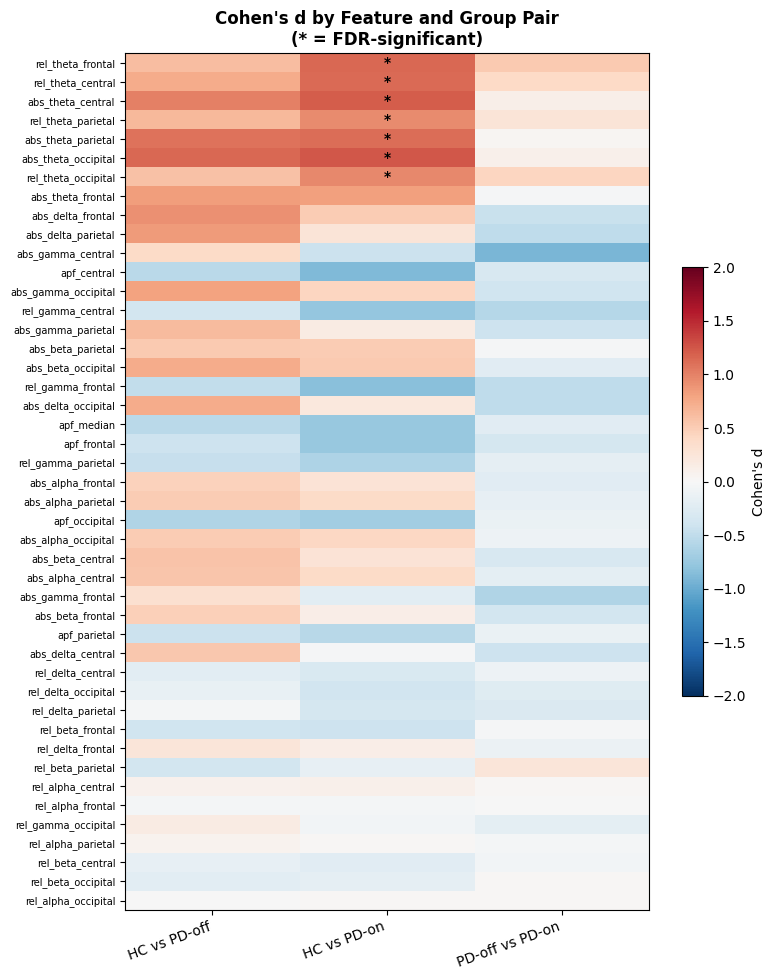

In [12]:
pair_labels = [f'{g1} vs {g2}' for g1, g2 in PAIRS]
d_cols  = [f'd_{pair_key(g1,g2)}'   for g1,g2 in PAIRS]
sig_cols = [f'sig_{pair_key(g1,g2)}' for g1,g2 in PAIRS]

# Build matrix: features × pairs
d_matrix  = summary_df[d_cols].values
sig_matrix = summary_df[sig_cols].values.astype(bool)
features   = summary_df['feature'].values

fig, ax = plt.subplots(figsize=(8, max(8, len(features) * 0.22)))
im = ax.imshow(d_matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)

ax.set_xticks(range(len(pair_labels)))
ax.set_xticklabels(pair_labels, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=7)

# Mark significant cells with *
for ri in range(len(features)):
    for ci in range(len(PAIRS)):
        if sig_matrix[ri, ci]:
            ax.text(ci, ri, '*', ha='center', va='center', fontsize=10,
                    color='black', fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.5, label="Cohen's d")
ax.set_title("Cohen's d by Feature and Group Pair\n(* = FDR-significant)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4.2.3. Mann-Whitney U Significance

Three-panel bar chart showing -log10(FDR-corrected p-value) per feature for each group pair. The dashed line is the α=0.05 threshold — bars crossing it are FDR-significant. Red bars = significant; blue = not significant.

This plot differs from the Cohen's d heatmap: it shows **statistical confidence** (p-value) rather than **effect magnitude** (d). A feature can have a large Cohen's d but not survive FDR correction (common at small n), so reading both plots together gives the full picture.

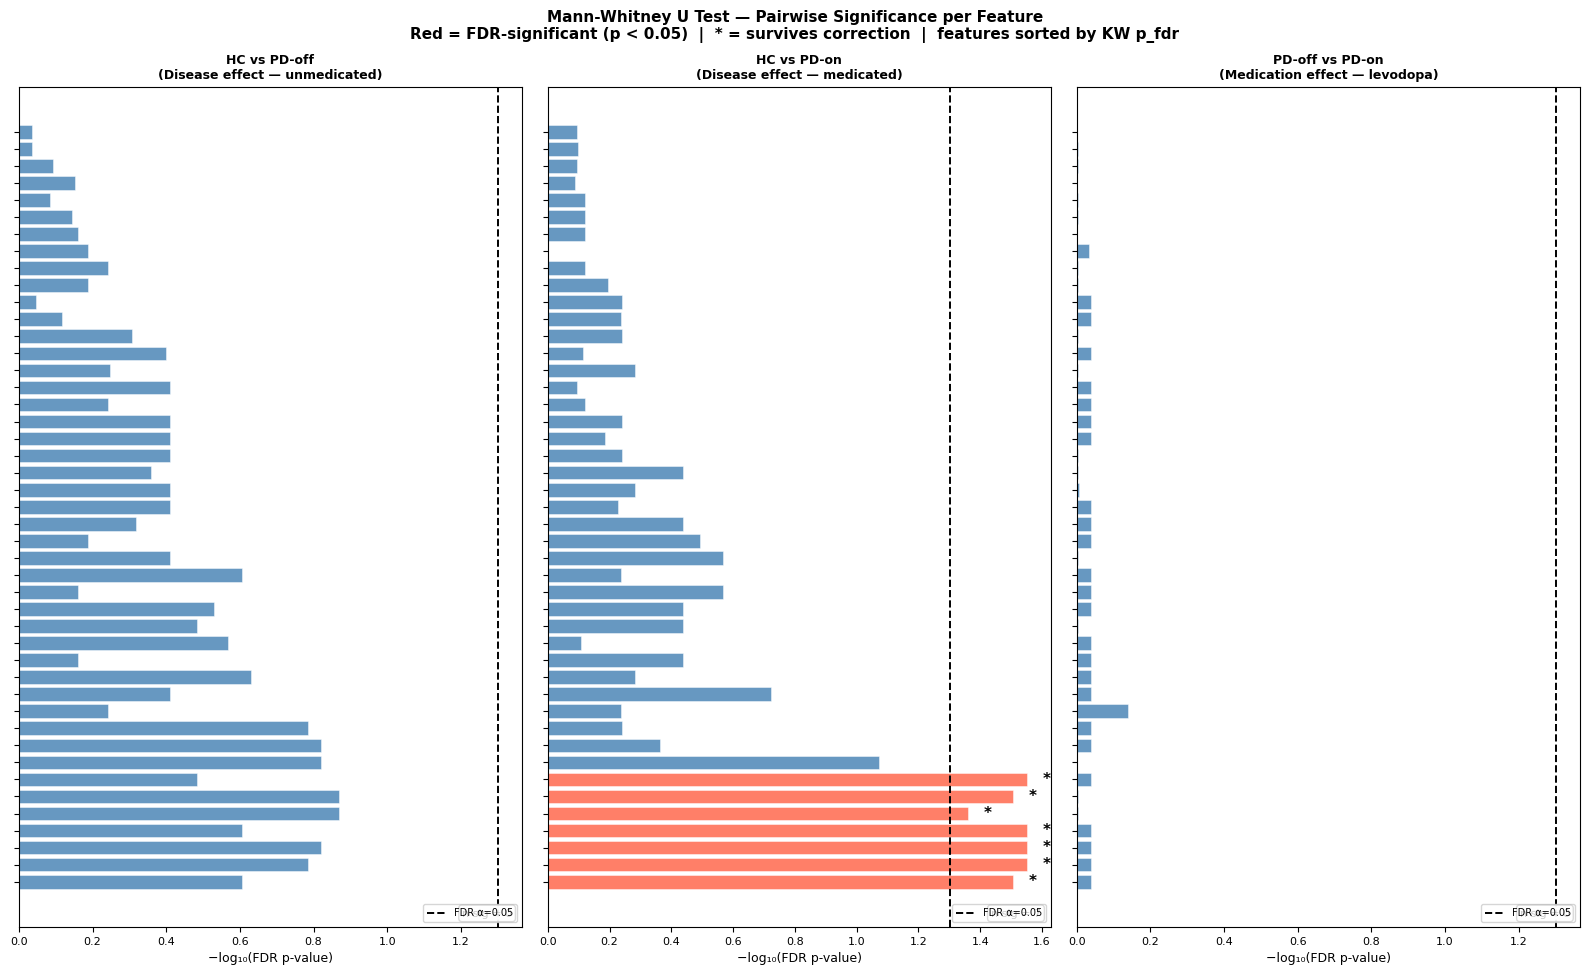

Significant features per pair (FDR p < 0.05):
  HC vs PD-off (0): none
  HC vs PD-on (7): ['rel_theta_frontal', 'rel_theta_central', 'abs_theta_central', 'rel_theta_parietal', 'abs_theta_parietal', 'abs_theta_occipital', 'rel_theta_occipital']
  PD-off vs PD-on (0): none


In [14]:
# ── Mann-Whitney U significance: 3-panel horizontal bar chart ────────────────
p_fdr_cols  = [f'p_fdr_{pair_key(g1,g2)}' for g1, g2 in PAIRS]
sig_cols_mw = [f'sig_{pair_key(g1,g2)}'   for g1, g2 in PAIRS]

feat_order    = summary_df['feature'].values          # already sorted by KW p_fdr
p_matrix      = summary_df[p_fdr_cols].clip(lower=1e-10).values
sig_matrix_mw = summary_df[sig_cols_mw].values.astype(bool)
log_p_matrix  = -np.log10(p_matrix)
threshold_line = -np.log10(ALPHA)

pair_titles = [
    'HC vs PD-off\n(Disease effect — unmedicated)',
    'HC vs PD-on\n(Disease effect — medicated)',
    'PD-off vs PD-on\n(Medication effect — levodopa)',
]

fig, axes = plt.subplots(1, 3, figsize=(16, max(8, len(feat_order) * 0.22)), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ci, (ax, title) in enumerate(zip(axes, pair_titles)):
    vals   = log_p_matrix[:, ci]
    colors = ['tomato' if sig_matrix_mw[ri, ci] else 'steelblue'
              for ri in range(len(feat_order))]

    ax.barh(range(len(feat_order)), vals, color=colors, alpha=0.82,
            edgecolor='white', linewidth=0.4)
    ax.axvline(threshold_line, color='black', linestyle='--', linewidth=1.4,
               label=f'FDR α={ALPHA}')

    # Star annotation on significant bars
    for ri in range(len(feat_order)):
        if sig_matrix_mw[ri, ci]:
            ax.text(vals[ri] + 0.05, ri, '*', va='center',
                    fontsize=11, fontweight='bold', color='black')

    ax.set_yticks(range(len(feat_order)))
    ax.set_yticklabels(feat_order if ci == 0 else [], fontsize=7)
    ax.set_xlabel('−log₁₀(FDR p-value)', fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=7, loc='lower right')

    n_sig = sig_matrix_mw[:, ci].sum()
    ax.text(0.98, 0.01, f'n sig = {n_sig}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.suptitle(
    'Mann-Whitney U Test — Pairwise Significance per Feature\n'
    'Red = FDR-significant (p < 0.05)  |  * = survives correction  |  features sorted by KW p_fdr',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Significant features per pair (FDR p < 0.05):')
for ci, (g1, g2) in enumerate(PAIRS):
    sig_feats = feat_order[sig_matrix_mw[:, ci]]
    print(f'  {g1} vs {g2} ({len(sig_feats)}): {list(sig_feats) if len(sig_feats) else "none"}')

## 5. Top Significant Features

Boxplots for the top 12 features ranked by Kruskal-Wallis FDR p-value.

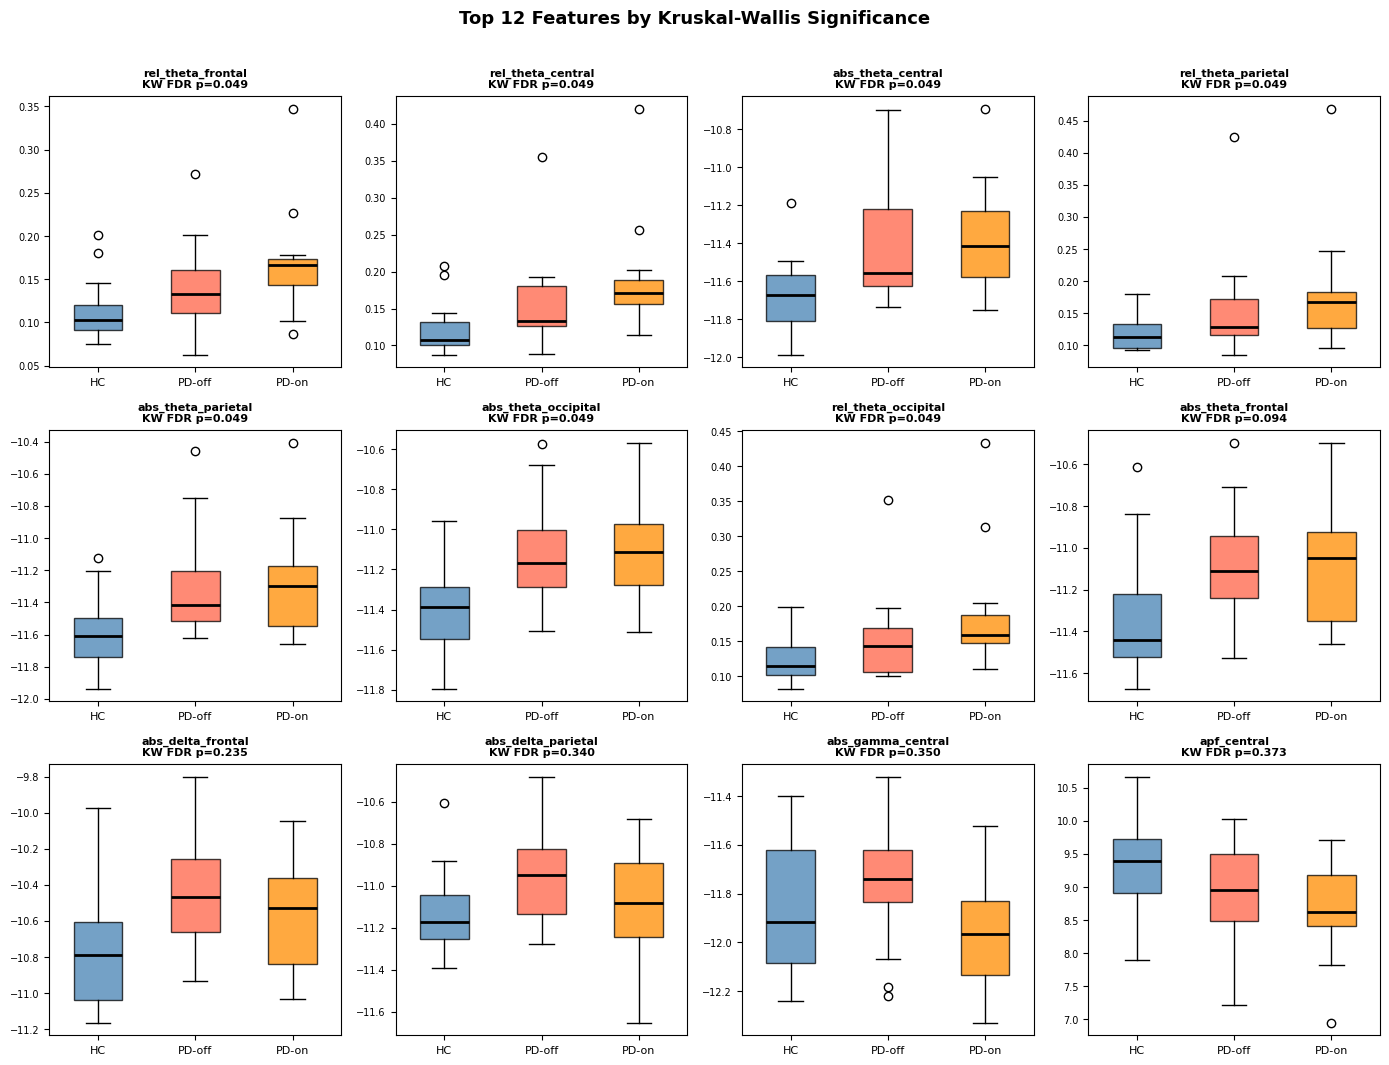

In [15]:
top_feats = summary_df.head(12)['feature'].values
group_colors = {'HC': 'steelblue', 'PD-off': 'tomato', 'PD-on': 'darkorange'}

ncols = 4
nrows = int(np.ceil(len(top_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    data_by_grp = [df[df['group'] == g][feat].dropna().values for g in GROUPS]
    bp = ax.boxplot(data_by_grp, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, grp in zip(bp['boxes'], GROUPS):
        patch.set_facecolor(group_colors[grp])
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['HC', 'PD-off', 'PD-on'], fontsize=8)
    kw_p = summary_df.loc[summary_df['feature'] == feat, 'KW_p_fdr'].values[0]
    ax.set_title(f'{feat}\nKW FDR p={kw_p:.3f}', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 12 Features by Kruskal-Wallis Significance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Medication Effect: PD-off vs PD-on

This comparison is clinically important: features that differ significantly between PD-off and PD-on reflect the neural response to levodopa therapy.

In [16]:
pk_med = pair_key('PD-off', 'PD-on')
med_df = summary_df[['feature', f'd_{pk_med}', f'p_fdr_{pk_med}', f'sig_{pk_med}']].copy()
med_df = med_df.sort_values(f'd_{pk_med}', key=abs, ascending=False)

print(f'Features with significant PD-off vs PD-on difference (FDR p < {ALPHA}):')
sig_med = med_df[med_df[f'sig_{pk_med}'] == True]
if len(sig_med) == 0:
    print('  None — medication effect not statistically significant after FDR correction.')
    print('  (Expected given n=15 per group; trends may still be visible in effect sizes.)')
else:
    print(sig_med[['feature', f'd_{pk_med}', f'p_fdr_{pk_med}']].to_string(index=False))

print()
print('Top 10 by |Cohen\'s d| (PD-off vs PD-on):')
print(med_df.head(10)[['feature', f'd_{pk_med}', f'p_fdr_{pk_med}']].to_string(index=False))

Features with significant PD-off vs PD-on difference (FDR p < 0.05):
  None — medication effect not statistically significant after FDR correction.
  (Expected given n=15 per group; trends may still be visible in effect sizes.)

Top 10 by |Cohen's d| (PD-off vs PD-on):
            feature  d_PDoff_vs_PDon  p_fdr_PDoff_vs_PDon
  abs_gamma_central           -0.911             0.726313
  abs_gamma_frontal           -0.594             0.912447
  rel_gamma_central           -0.567             0.912447
  rel_theta_frontal            0.524             0.912447
  rel_gamma_frontal           -0.510             0.912447
abs_delta_occipital           -0.504             0.912447
 abs_delta_parietal           -0.503             0.912447
  abs_delta_frontal           -0.441             0.912447
rel_theta_occipital            0.430             0.912447
 abs_gamma_parietal           -0.421             0.912447


## 7. Feature Selection for Next Notebook (06)

We select features for the classifier based on:
1. **Primary**: FDR-significant in Kruskal-Wallis (p_fdr < 0.05)
2. **Fallback**: If fewer than 5 KW-significant features, use top features by effect size (|d| ≥ 0.5, HC vs PD-off)

Selected features are saved to `processed/selected_features.txt` for use in notebook 06.

In [17]:
# Primary selection: KW FDR-significant
selected = summary_df[summary_df['significant'] == True]['feature'].tolist()

# Fallback: effect size threshold
if len(selected) < 5:
    pk_hcpd = pair_key('HC', 'PD-off')
    fallback = summary_df[summary_df[f'd_{pk_hcpd}'].abs() >= 0.5]['feature'].tolist()
    selected = list(dict.fromkeys(selected + fallback))  # deduplicate, preserve order
    print(f'KW significant < 5 — added effect-size fallback features.')

print(f'Selected {len(selected)} features for notebook 06:')
for f in selected:
    print(f'  {f}')

# Save
sel_path = os.path.join(PROC_DIR, 'selected_features.txt')
with open(sel_path, 'w') as fp:
    fp.write('\n'.join(selected))
print(f'\nSaved to: {sel_path}')

Selected 7 features for notebook 06:
  rel_theta_frontal
  rel_theta_central
  abs_theta_central
  rel_theta_parietal
  abs_theta_parietal
  abs_theta_occipital
  rel_theta_occipital

Saved to: processed\selected_features.txt


## 8. Conclusions

### 8.1. Statistical Analysis Results

#### 8.1.1. Normality  
Shapiro-Wilk tests show that 80.7% of feature-group pairs are consistent with normality (109/135), but violations are concentrated in **relative power features** — particularly `rel_theta` and `rel_gamma` bands — and are consistent across all three groups (HC: 82.2%, PD-off: 80.0%, PD-on: 80.0%). Given the small sample size (n ≈ 15–16 per group) and the systematic nature of these violations, non-parametric tests were used throughout.

#### 8.1.2. Kruskal-Wallis (3-group omnibus)  
Of 45 features tested, 9 reach raw p < 0.05 and **7 survive Benjamini-Hochberg FDR correction**. All 7 significant features are **theta-band features** spanning frontal, central, parietal, and occipital ROIs — both absolute and relative power. No delta, alpha, beta, or gamma features survive FDR correction. `abs_theta_frontal` approaches but does not meet the threshold (FDR p = 0.094). This confirms **theta as the sole FDR-robust biomarker** distinguishing the three groups in this cohort.

| Feature | KW stat | FDR p |
|---------|---------|-------|
| rel_theta_central | 13.148 | 0.049 |
| abs_theta_occipital | 11.083 | 0.049 |
| abs_theta_central | 11.038 | 0.049 |
| abs_theta_parietal | 10.284 | 0.049 |
| rel_theta_frontal | 10.126 | 0.049 |
| rel_theta_parietal | 9.977 | 0.049 |
| rel_theta_occipital | 9.769 | 0.049 |

#### 8.1.3. Post-hoc pairwise (HC vs PD-off, HC vs PD-on, PD-off vs PD-on)  
- **HC vs PD-off**: Large effect sizes across all 7 theta features (|d| = 0.58–1.16), but **zero features survive FDR correction** after pairwise adjustment. The unmedicated disease effect is present at the effect-size level but underpowered at n=15 per group.  
- **HC vs PD-on**: **All 7 theta features are FDR-significant** (p_fdr ≈ 0.049), with the largest effect sizes in the dataset (|d| = 0.94–1.24). Notably, the medicated PD group shows *greater* statistical separation from HC than the unmedicated group — a counter-intuitive finding discussed in the Q&A below.  
- **PD-off vs PD-on**: **No features survive FDR correction**. Effect sizes are small to moderate (max |d| = 0.52 for rel_theta_frontal), consistent with an underpowered medication comparison at n=15 per group.

#### 8.1.4. Effect sizes  
Absolute theta features show the largest Cohen's d for HC vs PD-off (`abs_theta_occipital` d=1.16, `abs_theta_parietal` d=1.08, `abs_theta_central` d=1.01). For HC vs PD-on, absolute and relative theta features are comparable (`abs_theta_occipital` d=1.24 vs `rel_theta_frontal` d=1.14). APF features show a consistent **negative** Cohen's d (apf_central: d=−0.54 for HC vs PD-off, d=−0.88 for HC vs PD-on), confirming alpha-peak slowing in PD — though this does not survive FDR correction at this sample size. Gamma features show moderate effect sizes (abs_gamma_central d=−0.91 for PD-off vs PD-on) but no statistical significance.

#### 8.1.5. Feature selection  
7 theta-band features selected for notebook 06 (4 relative, 3 absolute):  
`rel_theta_frontal`, `rel_theta_central`, `abs_theta_central`, `rel_theta_parietal`, `abs_theta_parietal`, `abs_theta_occipital`, `rel_theta_occipital`  
Saved to `processed/selected_features.txt`.

### 8.2. Q&A: Understanding the Counter-Intuitive Results

#### 8.2.1. Q1: Why is HC vs PD-on more statistically significant than HC vs PD-off?  

The short answer is that **PD-on has even higher theta power than PD-off** — theta does not normalize back toward HC levels after levodopa; it increases further. The group means reveal a monotonic ordering:

```
HC < PD-off < PD-on   (in theta power)
```

For example, `rel_theta_frontal`:

| Group | Mean ± SD | Gap from HC |
|-------|-----------|-------------|
| HC | 0.114 ± 0.035 | — |
| PD-off | 0.141 ± 0.050 | +0.027 |
| PD-on | 0.170 ± 0.059 | +0.056 |

PD-on sits roughly **twice as far from HC** as PD-off does. A larger separation produces a larger Cohen's d and a smaller p-value, which is why HC vs PD-on survives FDR correction while HC vs PD-off does not.

Why might levodopa *increase* theta rather than normalize it?
- **Dopaminergic modulation of frontal theta**: Levodopa restores dopamine levels in mesolimbic and mesocortical pathways — and dopamine is known to *drive* frontal theta rhythms (associated with working memory and cognitive engagement), not suppress them.
- **Improved alertness and engagement**: PD patients "on" medication feel better and are more cognitively active during resting-state recording, which can increase frontal theta.
- **PD-off instability**: In the medication-off state, patients experience fluctuating tremor and rigidity. This physiological noise may increase within-group variability in PD-off, spreading the distribution and partially masking the group shift.

#### 8.2.2. Q2: Does HC vs PD-off have no differences? Does the FDR result mean PD-off brains are normal?  

No — **the difference between HC and PD-off is real and large**. Cohen's d of 0.58–1.16 across 7 theta features is a biologically meaningful effect (anything above 0.8 is considered large). The absence of FDR significance is purely a **statistical power limitation**, not evidence of no effect. Three factors work against HC vs PD-off in the pairwise test:

1. **Smaller mean gap** — PD-off is elevated above HC, but not as much as PD-on (see table above).
2. **High within-group variability in PD-off** — the off-state is physiologically unstable (e.g., `rel_theta_parietal` CV = 0.51 in PD-off vs 0.23 in HC). Greater spread in one group inflates the pooled standard deviation, which reduces Cohen's d and statistical power.
3. **Underpowered pairwise FDR at n=15** — the KW omnibus test pools all 46 observations and *does* survive FDR, confirming the 3-group effect is real. The pairwise test isolates only 16 (HC) vs 15 (PD-off), which at these effect sizes is simply not enough to cross the corrected significance threshold.

A practical way to see this: if the HC vs PD-off effect sizes were entered into a power calculation, you would need approximately **n=25–30 per group** to reliably detect them at FDR-corrected α=0.05. This cohort has n=15–16.

#### 8.2.3. Q3: What does this mean for the classifier in notebook 06?  

The FDR result should not drive feature selection — the 7 selected theta features are appropriate regardless. For the classifier, what matters is that **both PD-off and PD-on are separable from HC at the effect-size level**. Since the task includes a binary HC vs PD comparison (collapsing both medication states), the large Cohen's d values (up to 1.24) suggest the classifier should perform well. For the 3-class problem (HC / PD-off / PD-on), the PD-off vs PD-on boundary will be the hardest to learn given the small d values there (max 0.52).

### 8.3. Caveats

- **Small sample size (n=46, ~15–16 per group)**: Statistical power is limited. HC vs PD-off shows large Cohen's d values (up to 1.16) but no pairwise FDR-significant results — this is a power limitation, not an absence of effect. Effect sizes are more informative than p-values for feature selection at this n.
- **Counter-intuitive HC vs PD-on > HC vs PD-off significance**: The stronger statistical separation for the medicated group warrants caution. It may reflect preserved theta elevation under levodopa, lower within-session variability in PD-on recordings, or an artifact of treating the two PD sessions as independent observations.
- **Three-class problem**: The KW omnibus test captures any 3-group difference; the clinically most important contrast is HC vs PD-off. Despite the pairwise FDR result favoring HC vs PD-on, the large effect sizes in HC vs PD-off confirm the disease signal is real and should be the primary focus in notebook 06 classification.
- **No multiple-session correction**: HC contributes 1 session; PD subjects contribute 2 (ses-off, ses-on). Sessions are treated as independent observations, which inflates the effective PD sample slightly and introduces within-subject correlation that standard tests do not account for.
